In [2]:
# imports and notebook setup
from pathlib import Path
import importlib
import json
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")

import numpy as np
import torch

REPO_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "calvin_experiments" / "calvin_rollout_utils.py").exists()
)
for path in [REPO_ROOT, REPO_ROOT / "robomimic", REPO_ROOT / "calvin" / "calvin_env", REPO_ROOT / "calvin_experiments"]:
    path = str(path)
    if path not in sys.path:
        sys.path.insert(0, path)

import robomimic.envs
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.torch_utils as TorchUtils

import calvin_experiments.calvin_rollout_utils as CalvinRolloutUtils

CalvinRolloutUtils = importlib.reload(CalvinRolloutUtils)
from calvin_experiments.calvin_rollout_utils import (
    articulated_binaries_from_start_state,
    capture_scene_snapshot,
    check_state_difference,
    classify_behavior,
    fixed_scene_robot_from_config,
    is_env_connected,
    load_json_config,
    policy_epoch_from_checkpoint,
    plot_rollouts_from_trace_summaries,
    render_visual_camera,
    run_folder_name,
    reset_env_to_scene_robot,
    resolve_checkpoint_path,
    save_rollout_artifacts,
    seed_everything,
)

CONFIG_DIR = REPO_ROOT / "calvin_experiments" / "configs"
VISUALIZATION_CONFIG_PATH = CONFIG_DIR / "visualization_freiburg_style.json"
CHECKPOINT_PATH = REPO_ROOT / "outputs/calvin/base_policy/calvin_D_base_dp/20260501015147/models/model_epoch_280.pth"
OUTPUT_ROOT = REPO_ROOT / "outputs" / "calvin" / "base_tests"
VIDEO_FPS = 30
SCENE_CONFIG_PATH = CONFIG_DIR / "blocks_hidden.json"
SCENE_CONFIG_NAME = load_json_config(SCENE_CONFIG_PATH)["name"]



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [18]:
# load policy and environment
checkpoint_path = resolve_checkpoint_path(CHECKPOINT_PATH, REPO_ROOT)
POLICY_EPOCH = policy_epoch_from_checkpoint(checkpoint_path)

device = TorchUtils.get_torch_device(try_to_use_cuda=True)
policy, ckpt_dict = FileUtils.policy_from_checkpoint(
    ckpt_path=str(checkpoint_path),
    device=device,
    verbose=True,
)

env, _ = FileUtils.env_from_checkpoint(
    ckpt_dict=ckpt_dict,
    render=False,
    render_offscreen=True,
    verbose=True,
)
if not is_env_connected(env):
    raise RuntimeError("Loaded env is disconnected immediately after env_from_checkpoint.")
base_env_state = {key: np.asarray(value, dtype=np.float32).copy() for key, value in env.get_state().items()}
loaded_checkpoint_path = checkpoint_path
print(f"Loaded policy and env once from: {loaded_checkpoint_path}")
print(f"Policy epoch: {POLICY_EPOCH}")



============= Loaded Config =============
{
    "algo_name": "diffusion_policy",
    "experiment": {
        "name": "calvin_D_base_dp",
        "validate": true,
        "logging": {
            "terminal_output_to_txt": true,
            "log_tb": true,
            "log_wandb": true,
            "wandb_proj_name": "CALVIN"
        },
        "save": {
            "enabled": true,
            "every_n_seconds": null,
            "every_n_epochs": 20,
            "epochs": [],
            "on_best_validation": false,
            "on_best_rollout_return": false,
            "on_best_rollout_success_rate": true
        },
        "epoch_every_n_steps": 500,
        "validation_epoch_every_n_steps": 10,
        "env": null,
        "additional_envs": null,
        "render": false,
        "render_video": true,
        "keep_all_videos": false,
        "video_skip": 1,
        "rollout": {
            "enabled": true,
            "n": 10,
            "horizon": 150,
            "rate": 10,

In [23]:
# run base policy rollouts
GLOBAL_SEED = 2
ROBOT_STATE_OVERRIDE = None
NUM_ROLLOUTS = 20
HORIZON = 100
STOP_ON_BEHAVIOR = True
FOR_DISPLAY_STOP = False
RECREATE_ENV_EACH_ROLLOUT = True  # Avoid hidden PyBullet/CALVIN state leaking across notebook reruns.

if "policy" not in globals() or "env" not in globals():
    raise RuntimeError("Run the policy loading cell before running rollouts.")
if not RECREATE_ENV_EACH_ROLLOUT and not is_env_connected(env):
    if "ckpt_dict" not in globals():
        raise RuntimeError("Loaded env is disconnected and ckpt_dict is unavailable. Rerun the policy loading cell.")
    print("Loaded env is disconnected; recreating env from checkpoint metadata.")
    env, _ = FileUtils.env_from_checkpoint(
        ckpt_dict=ckpt_dict,
        render=False,
        render_offscreen=True,
        verbose=True,
    )
    base_env_state = {key: np.asarray(value, dtype=np.float32).copy() for key, value in env.get_state().items()}

video_cfg = load_json_config(VISUALIZATION_CONFIG_PATH)
scene_cfg = load_json_config(SCENE_CONFIG_PATH)

output_root = Path(OUTPUT_ROOT)
if not output_root.is_absolute():
    output_root = REPO_ROOT / output_root

scene_name = scene_cfg["name"]
fps = int(VIDEO_FPS)
horizon = int(HORIZON)
num_rollouts = int(NUM_ROLLOUTS)
stop_on_behavior = bool(STOP_ON_BEHAVIOR)
for_display_stop = bool(FOR_DISPLAY_STOP)

run_id = run_folder_name(
    "base_policy",
    f"policy_{POLICY_EPOCH}",
    f"scene_{scene_name}",
    f"rollouts{num_rollouts}",
    f"horizon{horizon}",
    f"seed{GLOBAL_SEED if GLOBAL_SEED is not None else 'none'}",
)
policy_rollout_out_dir = output_root / run_id
policy_rollout_out_dir.mkdir(parents=True, exist_ok=True)
policy_rollout_summaries = []

seed_everything(GLOBAL_SEED)
for rollout_idx in range(num_rollouts):
    rollout_seed = None if GLOBAL_SEED is None else GLOBAL_SEED + rollout_idx
    if RECREATE_ENV_EACH_ROLLOUT:
        if is_env_connected(env):
            try:
                CalvinRolloutUtils.get_calvin_unwrapped_env(env).close()
            except Exception:
                pass
        seed_everything(rollout_seed)
        env, _ = FileUtils.env_from_checkpoint(
            ckpt_dict=ckpt_dict,
            render=False,
            render_offscreen=True,
            verbose=False,
        )
        if not is_env_connected(env):
            raise RuntimeError("Recreated env is disconnected immediately after env_from_checkpoint.")
        base_env_state = {key: np.asarray(value, dtype=np.float32).copy() for key, value in env.get_state().items()}

    fixed_scene, fixed_robot, scene_cfg = fixed_scene_robot_from_config(base_env_state, SCENE_CONFIG_PATH, ROBOT_STATE_OVERRIDE)
    seed_everything(rollout_seed)
    policy.start_episode()
    obs = reset_env_to_scene_robot(env, fixed_scene, fixed_robot)
    scene_snapshot = capture_scene_snapshot(env)
    start_state = env.get_state()
    start_scene = np.asarray(start_state["scene"], dtype=np.float32).copy()
    binaries = articulated_binaries_from_start_state(start_scene)

    frames = [render_visual_camera(env, video_cfg)]
    actions, rewards, dones = [], [], []
    scene_states = [start_scene.copy()]
    robot_states = [np.asarray(start_state["robot"], dtype=np.float32).copy()]
    eef_xy = [robot_states[-1][:2].copy()]

    detected_behavior = "none"
    detected_step = -1
    termination_reason = "horizon"

    for step in range(horizon):
        action = np.asarray(policy(ob=obs), dtype=np.float32).copy()
        actions.append(action.copy())
        obs, reward, done, info = env.step(action.copy())
        state = env.get_state()
        scene = np.asarray(state["scene"], dtype=np.float32).copy()
        robot = np.asarray(state["robot"], dtype=np.float32).copy()

        rewards.append(float(reward))
        dones.append(bool(done))
        scene_states.append(scene)
        robot_states.append(robot)
        eef_xy.append(robot[:2].copy())
        frames.append(render_visual_camera(env, video_cfg))

        triggered = check_state_difference(start_scene, scene, robot[:3], binaries, for_display=for_display_stop)
        if detected_step < 0 and triggered:
            detected_behavior = classify_behavior(start_scene, scene, robot[:3], binaries, for_display=for_display_stop)
            detected_step = step + 1
            if stop_on_behavior:
                termination_reason = "behavior"
                break
        if done:
            termination_reason = "env_done"
            break

    rollout = {
        "scene_config": scene_name,
        "seed": rollout_seed,
        "behavior": detected_behavior,
        "behavior_step": detected_step,
        "termination_step": len(actions),
        "termination_reason": termination_reason,
        "return": float(np.sum(rewards)),
        "actions": np.asarray(actions, dtype=np.float32),
        "rewards": np.asarray(rewards, dtype=np.float32),
        "dones": np.asarray(dones, dtype=bool),
        "scene_states": np.asarray(scene_states, dtype=np.float32),
        "robot_states": np.asarray(robot_states, dtype=np.float32),
        "eef_xy": np.asarray(eef_xy, dtype=np.float32),
        "scene_snapshot": scene_snapshot,
    }
    save_rollout_artifacts(rollout, frames, policy_rollout_out_dir, f"rollout_{rollout_idx:03d}", video_cfg, fps=fps)

    policy_rollout_summaries.append({
        "scene_config": scene_name,
        "rollout": rollout_idx,
        "seed": rollout_seed,
        "behavior": detected_behavior,
        "step": detected_step,
        "termination_step": len(actions),
        "termination_reason": termination_reason,
        "video": rollout["video"],
        "trace": rollout["trace"],
        "scene_snapshot": rollout["scene_snapshot_path"],
    })

summary_path = policy_rollout_out_dir / "policy_rollout_summary.json"
with open(summary_path, "w") as f:
    json.dump([{key: str(value) if isinstance(value, Path) else value for key, value in row.items()} for row in policy_rollout_summaries], f, indent=2)

print(f"Policy rollout output: {policy_rollout_out_dir}")
print(f"Summary JSON: {summary_path}")
print("Detected behaviors:")
for row in policy_rollout_summaries:
    print(
        f"{row['scene_config']} rollout {row['rollout']:03d} seed {row['seed']} -> "
        f"{row['behavior']} @ detected step {row['step']} | "
        f"terminated step {row['termination_step']} ({row['termination_reason']}) | "
        f"video: {row['video']}"
    )

if policy_rollout_summaries:
    try:
        from IPython.display import Video, display
        display(Video(filename=str(policy_rollout_summaries[0]["video"]), embed=True))
    except Exception as exc:
        print(f"Inline video display skipped: {exc}")



disconnecting id 0 from server
Destroy EGL OpenGL window.
argv[0]=--width=200
argv[1]=--height=200
Loaded EGL 1.5 after reload.
GL_VENDOR=NVIDIA Corporation
GL_RENDERER=NVIDIA GeForce RTX 3090/PCIe/SSE2
GL_VERSION=3.3.0 NVIDIA 580.126.09
GL_SHADING_LANGUAGE_VERSION=3.30 NVIDIA via Cg compiler
Version = 3.3.0 NVIDIA 580.126.09
Vendor = NVIDIA Corporation
Renderer = NVIDIA GeForce RTX 3090/PCIe/SSE2
Created environment with name PlayTableSimEnv
Action size is 7
ROBOMIMIC WARNING(
    No environment version found in dataset!
    Cannot verify if dataset and installed environment versions match
)
disconnecting id -1 from server
ven = NVIDIA Corporation
ven = NVIDIA Corporation


EGL device choice: -1 of 3.


disconnecting id 0 from server
Destroy EGL OpenGL window.
argv[0]=--width=200
argv[1]=--height=200
Loaded EGL 1.5 after reload.
GL_VENDOR=NVIDIA Corporation
GL_RENDERER=NVIDIA GeForce RTX 3090/PCIe/SSE2
GL_VERSION=3.3.0 NVIDIA 580.126.09
GL_SHADING_LANGUAGE_VERSION=3.30 NVIDIA via Cg compiler
Version = 3.3.0 NVIDIA 580.126.09
Vendor = NVIDIA Corporation
Renderer = NVIDIA GeForce RTX 3090/PCIe/SSE2
Created environment with name PlayTableSimEnv
Action size is 7
ROBOMIMIC WARNING(
    No environment version found in dataset!
    Cannot verify if dataset and installed environment versions match
)
disconnecting id -1 from server
ven = NVIDIA Corporation
ven = NVIDIA Corporation


EGL device choice: -1 of 3.


disconnecting id 0 from server
Destroy EGL OpenGL window.
argv[0]=--width=200
argv[1]=--height=200
Loaded EGL 1.5 after reload.
GL_VENDOR=NVIDIA Corporation
GL_RENDERER=NVIDIA GeForce RTX 3090/PCIe/SSE2
GL_VERSION=3.3.0 NVIDIA 580.126.09
GL_SHADING_LANGUAGE_VERSION=3.30 NVIDIA via Cg compiler
Version = 3.3.0 NVIDIA 580.126.09
Vendor = NVIDIA Corporation
Renderer = NVIDIA GeForce RTX 3090/PCIe/SSE2
Created environment with name PlayTableSimEnv
Action size is 7
ROBOMIMIC WARNING(
    No environment version found in dataset!
    Cannot verify if dataset and installed environment versions match
)
disconnecting id -1 from server
ven = NVIDIA Corporation
ven = NVIDIA Corporation


...

disconnecting id 0 from server
Destroy EGL OpenGL window.
argv[0]=--width=200
argv[1]=--height=200
Loaded EGL 1.5 after reload.
GL_VENDOR=NVIDIA Corporation
GL_RENDERER=NVIDIA GeForce RTX 3090/PCIe/SSE2
GL_VERSION=3.3.0 NVIDIA 580.126.09
GL_SHADING_LANGUAGE_VERSION=3.30 NVIDIA via Cg compiler
Version = 3.3.0 NVIDIA 580.126.09
Vendor = NVIDIA Corporation
Renderer = NVIDIA GeForce RTX 3090/PCIe/SSE2
Created environment with name PlayTableSimEnv
Action size is 7
ROBOMIMIC WARNING(
    No environment version found in dataset!
    Cannot verify if dataset and installed environment versions match
)
disconnecting id -1 from server
ven = NVIDIA Corporation
ven = NVIDIA Corporation


EGL device choice: -1 of 3.


disconnecting id 0 from server
Destroy EGL OpenGL window.
argv[0]=--width=200
argv[1]=--height=200
Loaded EGL 1.5 after reload.
GL_VENDOR=NVIDIA Corporation
GL_RENDERER=NVIDIA GeForce RTX 3090/PCIe/SSE2
GL_VERSION=3.3.0 NVIDIA 580.126.09
GL_SHADING_LANGUAGE_VERSION=3.30 NVIDIA via Cg compiler
Version = 3.3.0 NVIDIA 580.126.09
Vendor = NVIDIA Corporation
Renderer = NVIDIA GeForce RTX 3090/PCIe/SSE2
Created environment with name PlayTableSimEnv
Action size is 7
ROBOMIMIC WARNING(
    No environment version found in dataset!
    Cannot verify if dataset and installed environment versions match
)
disconnecting id -1 from server
ven = NVIDIA Corporation
ven = NVIDIA Corporation


EGL device choice: -1 of 3.


Policy rollout output: /home/moritz/src/guided-diffusion/outputs/calvin/base_tests/base_policy_policy_epoch280_scene_blocks_hidden_rollouts20_horizon100_seed2_05-05-26__14-50-37
Summary JSON: /home/moritz/src/guided-diffusion/outputs/calvin/base_tests/base_policy_policy_epoch280_scene_blocks_hidden_rollouts20_horizon100_seed2_05-05-26__14-50-37/policy_rollout_summary.json
Detected behaviors:
blocks_hidden rollout 000 seed 2 -> drawer_open @ detected step 63 | terminated step 63 (behavior) | video: /home/moritz/src/guided-diffusion/outputs/calvin/base_tests/base_policy_policy_epoch280_scene_blocks_hidden_rollouts20_horizon100_seed2_05-05-26__14-50-37/rollout_000/blocks_hidden_rollout_000_freiburg_style.mp4
blocks_hidden rollout 001 seed 3 -> none @ detected step -1 | terminated step 100 (horizon) | video: /home/moritz/src/guided-diffusion/outputs/calvin/base_tests/base_policy_policy_epoch280_scene_blocks_hidden_rollouts20_horizon100_seed2_05-05-26__14-50-37/rollout_001/blocks_hidden_rol

plot: /home/moritz/src/guided-diffusion/outputs/calvin/base_tests/base_policy_policy_epoch280_scene_blocks_hidden_rollouts20_horizon100_seed2_05-05-26__14-50-37/rollout_scene_overlay_all.png


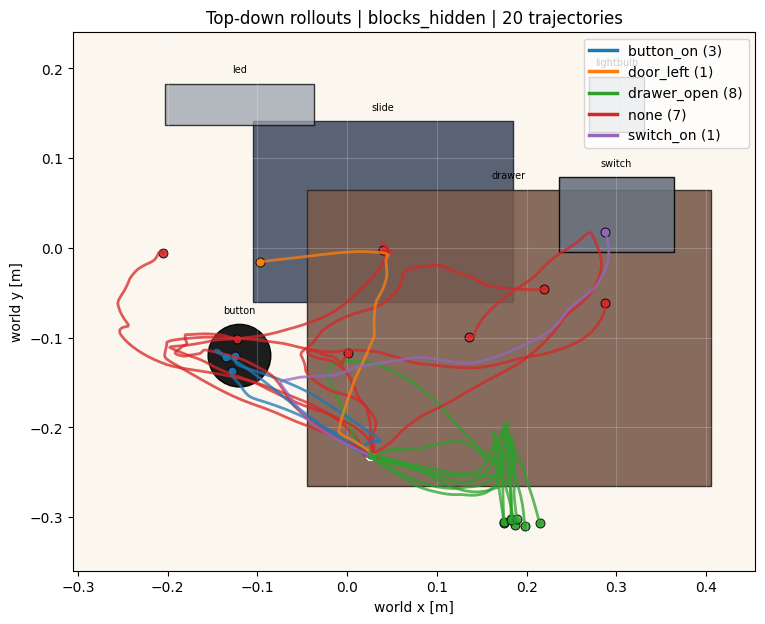

In [24]:
# plot rollout xy overlay
if "policy_rollout_summaries" not in globals() or not policy_rollout_summaries:
    print("Run the policy rollout cell above first; it writes trace .npz files for plotting.")
else:
    plot_rollouts_from_trace_summaries(policy_rollout_summaries)


In [25]:
# sweep all base-policy checkpoints for behavior preference
from collections import Counter
import time

MODEL_SWEEP_DIR = REPO_ROOT / "outputs/calvin/base_policy/calvin_D_base_dp/20260501015147/models"
SWEEP_N_ROLLOUTS = 20
SWEEP_SEED_START = 0
SWEEP_HORIZON = 100
SWEEP_STOP_ON_BEHAVIOR = True
SWEEP_FOR_DISPLAY_STOP = False
SWEEP_ROBOT_STATE_OVERRIDE = globals().get("ROBOT_STATE_OVERRIDE", None)

sweep_output_dir = OUTPUT_ROOT / run_folder_name(
    "policy_model_sweep",
    f"scene_{SCENE_CONFIG_NAME}",
    f"models_all",
    f"rollouts{SWEEP_N_ROLLOUTS}",
    f"horizon{SWEEP_HORIZON}",
    f"seed{SWEEP_SEED_START}",
)
sweep_output_dir.mkdir(parents=True, exist_ok=True)

def _checkpoint_epoch(path):
    name = Path(path).stem
    if "epoch_" not in name:
        return 10**9
    tail = name.split("epoch_", 1)[1].split("_", 1)[0]
    return int(tail) if tail.isdigit() else 10**9


def _close_env_quietly(env_to_close):
    if env_to_close is None:
        return
    try:
        if is_env_connected(env_to_close):
            CalvinRolloutUtils.get_calvin_unwrapped_env(env_to_close).close()
    except Exception:
        pass


def _single_behavior_rollout(policy_to_eval, ckpt_for_env, seed, horizon):
    sweep_env = None
    try:
        seed_everything(seed)
        sweep_env, _ = FileUtils.env_from_checkpoint(
            ckpt_dict=ckpt_for_env,
            render=False,
            render_offscreen=True,
            verbose=False,
        )
        if not is_env_connected(sweep_env):
            raise RuntimeError("Sweep env disconnected immediately after env_from_checkpoint.")

        base_state = {key: np.asarray(value, dtype=np.float32).copy() for key, value in sweep_env.get_state().items()}
        fixed_scene, fixed_robot, _ = fixed_scene_robot_from_config(base_state, SCENE_CONFIG_PATH, SWEEP_ROBOT_STATE_OVERRIDE)

        seed_everything(seed)
        policy_to_eval.start_episode()
        obs = reset_env_to_scene_robot(sweep_env, fixed_scene, fixed_robot)
        start_state = sweep_env.get_state()
        start_scene = np.asarray(start_state["scene"], dtype=np.float32).copy()
        binaries = articulated_binaries_from_start_state(start_scene)

        detected_behavior = "none"
        detected_step = -1
        termination_reason = "horizon"
        steps = 0

        for step in range(int(horizon)):
            action = np.asarray(policy_to_eval(ob=obs), dtype=np.float32).copy()
            obs, reward, done, info = sweep_env.step(action.copy())
            state = sweep_env.get_state()
            scene = np.asarray(state["scene"], dtype=np.float32).copy()
            robot = np.asarray(state["robot"], dtype=np.float32).copy()
            steps = step + 1

            triggered = check_state_difference(start_scene, scene, robot[:3], binaries, for_display=SWEEP_FOR_DISPLAY_STOP)
            if detected_step < 0 and triggered:
                detected_behavior = classify_behavior(start_scene, scene, robot[:3], binaries, for_display=SWEEP_FOR_DISPLAY_STOP)
                detected_step = steps
                if SWEEP_STOP_ON_BEHAVIOR:
                    termination_reason = "behavior"
                    break
            if done:
                termination_reason = "env_done"
                break

        return {
            "seed": int(seed),
            "behavior": detected_behavior,
            "behavior_step": int(detected_step),
            "termination_step": int(steps),
            "termination_reason": termination_reason,
        }
    finally:
        _close_env_quietly(sweep_env)


model_paths = sorted(MODEL_SWEEP_DIR.glob("model_epoch_*.pth"), key=_checkpoint_epoch)
if not model_paths:
    raise FileNotFoundError(f"No model_epoch_*.pth files found in {MODEL_SWEEP_DIR}")

sweep_rows = []
print(f"Sweeping {len(model_paths)} checkpoints x {SWEEP_N_ROLLOUTS} rollouts -> {sweep_output_dir}")
print("epoch    found/total  none  switch  button  drawer  other  avg_hit_step  dominant")
print("-" * 82)

for model_idx, model_path in enumerate(model_paths, start=1):
    epoch = _checkpoint_epoch(model_path)
    print(f"[{model_idx:02d}/{len(model_paths):02d}] loading {model_path.name}")
    policy_eval, ckpt_eval = FileUtils.policy_from_checkpoint(
        ckpt_path=str(model_path),
        device=device,
        verbose=False,
    )

    rollout_rows = []
    for rollout_idx in range(int(SWEEP_N_ROLLOUTS)):
        rollout_seed = int(SWEEP_SEED_START + rollout_idx)
        row = _single_behavior_rollout(policy_eval, ckpt_eval, rollout_seed, SWEEP_HORIZON)
        rollout_rows.append(row)
        print(f"    {rollout_idx + 1:02d}/{SWEEP_N_ROLLOUTS}: seed={rollout_seed} -> {row['behavior']} @ {row['behavior_step']}")

    counts = Counter(row["behavior"] for row in rollout_rows)
    found = int(SWEEP_N_ROLLOUTS - counts.get("none", 0))
    hit_steps = [row["behavior_step"] for row in rollout_rows if row["behavior_step"] > 0]
    avg_hit_step = float(np.mean(hit_steps)) if hit_steps else float("nan")
    other_count = found - counts.get("switch_on", 0) - counts.get("button_on", 0) - counts.get("drawer_open", 0)
    dominant = counts.most_common(1)[0][0]

    summary = {
        "checkpoint": str(model_path),
        "epoch": int(epoch),
        "n_rollouts": int(SWEEP_N_ROLLOUTS),
        "seed_start": int(SWEEP_SEED_START),
        "horizon": int(SWEEP_HORIZON),
        "counts": dict(sorted(counts.items())),
        "found": found,
        "avg_hit_step": avg_hit_step,
        "rollouts": rollout_rows,
    }
    sweep_rows.append(summary)

    avg_text = f"{avg_hit_step:6.1f}" if hit_steps else "   n/a"
    print(
        f"{epoch:>5}    {found:>2}/{SWEEP_N_ROLLOUTS:<5}"
        f"  {counts.get('none', 0):>4}"
        f"  {counts.get('switch_on', 0):>6}"
        f"  {counts.get('button_on', 0):>6}"
        f"  {counts.get('drawer_open', 0):>6}"
        f"  {other_count:>5}"
        f"  {avg_text:>12}  {dominant}"
    )
    print("-" * 82)
    del policy_eval
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

sweep_summary_path = sweep_output_dir / "policy_model_sweep_summary.json"
with open(sweep_summary_path, "w") as f:
    json.dump(sweep_rows, f, indent=2)

best_by_found = sorted(sweep_rows, key=lambda row: (row["found"], -row["avg_hit_step"] if np.isfinite(row["avg_hit_step"]) else -9999), reverse=True)
print(f"Sweep summary saved: {sweep_summary_path}")
print("Top checkpoints by any detected behavior:")
for row in best_by_found[:5]:
    print(f"  epoch {row['epoch']:>5}: found {row['found']:>2}/{row['n_rollouts']} | counts={row['counts']} | avg_hit_step={row['avg_hit_step']:.1f}")


Sweeping 15 checkpoints x 20 rollouts -> /home/moritz/src/guided-diffusion/outputs/calvin/base_tests/policy_model_sweep_scene_blocks_hidden_models_all_rollouts20_horizon100_seed0_05-05-26__14-57-01
epoch    found/total  none  switch  button  drawer  other  avg_hit_step  dominant
----------------------------------------------------------------------------------
[01/15] loading model_epoch_10_calvin_D_training_success_0.0.pth

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['proprio']
using obs modality: rgb with keys: ['third_person', 'eye_in_hand']
using obs modality: depth with keys: []
using obs modality: scan with keys: []
number of parameters: 6.931892e+07
argv[0]=--width=200
argv[1]=--height=200
Created environment with name PlayTableSimEnv
Action size is 7
ROBOMIMIC WARNING(
    No environment version found in dataset!
    Cannot verify if dataset and installed environment versions match
)
ObservationKeyToModalityDi

In [3]:
# print checkpoint sweep summary ordered by hit rate
SWEEP_BEHAVIOR_ORDER = [
    "switch_on",
    # "switch_off",
    "button_on",
    # "button_off",
    "drawer_open",
    # "drawer_close",
    "door_left",
    "door_right",
    "none",
]

if "sweep_rows" not in globals():
    summary_candidates = sorted(
        Path(OUTPUT_ROOT).glob("policy_model_sweep_*/policy_model_sweep_summary.json"),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    if not summary_candidates:
        raise RuntimeError("No sweep_rows in memory and no saved policy_model_sweep_summary.json found. Run the sweep cell first.")
    sweep_summary_path = summary_candidates[0]
    with open(sweep_summary_path, "r") as f:
        sweep_rows = json.load(f)
    print(f"Loaded sweep summary: {sweep_summary_path}")

ordered_rows = sorted(
    sweep_rows,
    key=lambda row: (
        row.get("found", 0) / max(row.get("n_rollouts", 1), 1),
        row.get("found", 0),
        -row.get("avg_hit_step", 10**9) if np.isfinite(row.get("avg_hit_step", float("nan"))) else -10**9,
    ),
    reverse=True,
)

print("Checkpoints ordered by hit rate")
for row in ordered_rows:
    counts = row.get("counts", {})
    total = int(row.get("n_rollouts", sum(counts.values())))
    found = int(row.get("found", total - counts.get("none", 0)))
    hit_rate = found / total if total else 0.0
    epoch = int(row.get("epoch", -1))
    behavior_counts = " | ".join(f"{name}: {int(counts.get(name, 0))}" for name in SWEEP_BEHAVIOR_ORDER)
    print(f"epoch {epoch:>5}: found {found:>2} / {total:<2} ({hit_rate:5.1%}) | {behavior_counts}")


Loaded sweep summary: /home/moritz/src/guided-diffusion/outputs/calvin/base_tests/policy_model_sweep_scene_blocks_hidden_models_all_rollouts20_horizon100_seed0_05-05-26__14-57-01/policy_model_sweep_summary.json
Checkpoints ordered by hit rate
epoch   120: found 12 / 20 (60.0%) | switch_on: 1 | button_on: 3 | drawer_open: 8 | door_left: 0 | door_right: 0 | none: 8
epoch   240: found 12 / 20 (60.0%) | switch_on: 5 | button_on: 0 | drawer_open: 7 | door_left: 0 | door_right: 0 | none: 8
epoch   160: found 11 / 20 (55.0%) | switch_on: 1 | button_on: 1 | drawer_open: 9 | door_left: 0 | door_right: 0 | none: 9
epoch   140: found 11 / 20 (55.0%) | switch_on: 0 | button_on: 2 | drawer_open: 9 | door_left: 0 | door_right: 0 | none: 9
epoch   180: found  9 / 20 (45.0%) | switch_on: 3 | button_on: 0 | drawer_open: 6 | door_left: 0 | door_right: 0 | none: 11
epoch   280: found  9 / 20 (45.0%) | switch_on: 3 | button_on: 1 | drawer_open: 3 | door_left: 2 | door_right: 0 | none: 11
epoch   100: foun

In [31]:
print(type(sweep_rows))

<class 'list'>
